# **MVP — Machine Learning & Analytics**

**Nome:** _Talles Augusto de Oliveira Rodrigues_  
**Matrícula:** _4052025002304_  
**Data:** _10/06/2026_  
**Dataset:** [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)  
**Tipo de problema:** _Classificação_

---

## **Contexto do dataset**

>_Pessoas com doenças cardiovasculares ou que apresentam alto risco cardiovascular (devido à presença de um ou mais fatores de risco, como hipertensão, diabetes, hiperlipidemia ou doenças já estabelecidas), precisam de detecção e manejo precoces, nos quais um modelo de aprendizado de máquina pode ser de grande ajuda._


# 1. Carga e verificação de dados


## 1.1 Atributos do dataset

| Coluna | Descrição | Tipo |
|---|---|---|
| Age | Idade do paciente (anos) | int |
| Sex | Sexo do paciente | string |
| ChestPaintype | Dor no peito tipo | string |
| RestingBP | Pressão Arterial em repouso (mm Hg) | int |
| Cholesterol | Colesterol sérico (mm/dl) | int |
| FastingBS | Glicemia em jejum | int |
| RestingECG | Resultados do eletrocardiograma em repouso | string |
| MaxHR | Frequência cardíaca máxima alcançada | int |
| ExerciseAngina | Angina induzida pelo exercício | string |
| Oldpeak | ST = Valor númerico medido em depressão | float |
| ST_Slope | Inclinação do segmento ST de exercício de pico | string |
| HeartDisease | Classe de saída (1: doença cardíaca, 0: Normal) | int |


## 1.2 Download do dataset

In [ ]:
import kagglehub
import pandas as pd
import os

# Download do dataset
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Caminho do dataset:", path)

# Verificar os arquivos disponíveis
print(os.listdir(path))

100%|██████████| 8.56k/8.56k [00:00<00:00, 14.7MB/s]

Extracting files...
Caminho do dataset: /root/.cache/kagglehub/datasets/fedesoriano/heart-failure-prediction/versions/1
['heart.csv']


## 1.3 Carregamento e análise dos dados

In [ ]:
# Carregar dataset
df = pd.read_csv(f"{path}/heart.csv")

# Primeiras linhas
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# Quantidade de valores nulos por coluna
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
# Verificar valores duplicados
print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


In [ ]:
# Resumo do dataset
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 918
Quantidade de colunas: 12


# 2. Definição do problema

>_As doenças cardiovasculares estão entre as principais causas de morte no mundo, sendo responsáveis por milhões de óbitos todos os anos. O diagnóstico precoce dessas condições é fundamental para aumentar as chances de tratamento adequado e reduzir riscos à saúde dos pacientes. Entretanto, identificar indivíduos com maior probabilidade de desenvolver doenças cardíacas nem sempre é uma tarefa simples, pois diversos fatores clínicos e fisiológicos devem ser analisados simultaneamente._

>_Neste trabalho, será desenvolvido um modelo de Machine Learning capaz de prever a presença ou ausência de doença cardíaca em pacientes com base em informações médicas e características clínicas, como idade, sexo, pressão arterial, colesterol, frequência cardíaca máxima, resultados de exames e outros indicadores relacionados à saúde cardiovascular._

>_O objetivo da solução é apoiar o processo de tomada de decisão médica, fornecendo uma estimativa da probabilidade de um paciente apresentar doença cardíaca. Trata-se de um problema de classificação supervisionada, no qual o modelo deverá prever uma das duas classes possíveis: presença de doença cardíaca (1) ou ausência de doença cardíaca (0)._

>_Os principais interessados nessa solução seriam profissionais da área da saúde, hospitais, clínicas e instituições de pesquisa, que poderiam utilizar ferramentas semelhantes para auxiliar na triagem de pacientes e na identificação precoce de casos que demandam maior atenção médica._

>_A relevância deste problema está no potencial de utilizar técnicas de inteligência artificial para apoiar diagnósticos clínicos, reduzir o tempo de análise dos dados dos pacientes e contribuir para decisões mais rápidas e precisas. Embora o modelo não substitua a avaliação médica, ele pode atuar como uma ferramenta complementar de apoio à decisão, auxiliando na identificação de padrões que nem sempre são facilmente percebidos por métodos tradicionais de análise._

## 2.1 Objetivo do MVP

>_O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a presença de doença cardíaca em pacientes a partir de características clínicas e resultados de exames. Os modelos serão comparados com uma abordagem baseline para identificar a solução com melhor desempenho preditivo._


## 2.2 Tipo de problema

**Tipo escolhido:** _Classificação_

**Justificativa:**
_O objetivo do modelo é prever se um paciente possui ou não doença cardíaca com base em suas características clínicas e resultados de exames. A variável alvo ("HeartDisease") possui apenas duas categorias possíveis, sendo 1 para presença de doença cardíaca e 0 para ausência, caracterizando um problema de classificação binária._

> **Observação:** A variável de saída é categórica (0 ou 1), o que define o problema como **classificação supervisionada binária**.

## 2.3 Premissas, hipóteses e critérios de sucesso

>***Hipóteses iniciais***

**Hipótese 1:** As características clínicas dos pacientes contêm informações suficientes para identificar padrões associados à presença de doença cardíaca.

**Hipótese 2:** Modelos de Machine Learning serão capazes de obter desempenho superior a uma abordagem baseline na classificação dos pacientes.

**Hipótese 3:** Variáveis como idade, pressão arterial, colesterol, frequência cardíaca máxima e angina induzida por exercício terão influência significativa na previsão da doença cardíaca.

>***Critérios de sucesso***

**Métrica principal:** F1-Score, por equilibrar precisão e recall em um problema de classificação binária.

**Resultado mínimo esperado:** Obter um F1-Score superior ao modelo baseline e alcançar desempenho igual ou superior a 80%.

**Restrição prática:** O modelo deve possuir baixo custo computacional, tempo de treinamento reduzido e permitir interpretação dos resultados para compreensão dos fatores que influenciam a previsão.

# 3. Ambiente, bibliotecas e reprodutibilidade

>Para garantir a reprodutibilidade dos resultados, foi definida uma semente fixa (SEED = 42), aplicada aos geradores aleatórios utilizados no projeto. Os experimentos foram executados em ambiente CPU, sendo suficiente para o volume de dados e complexidade dos modelos avaliados. As versões das bibliotecas utilizadas foram registradas para facilitar futuras reproduções do trabalho.

In [ ]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


In [ ]:
# Versões das bibliotecas

import sklearn
import scipy

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)

Pandas: 2.2.2
NumPy: 2.0.2
Scikit-Learn: 1.6.1
SciPy: 1.16.3


In [ ]:
# Função auxiliar
def evaluate_classification(y_true, y_pred, proba=None):

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    if proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, proba[:, 1])

    return metrics


def show_results_table(results_dict):
    return pd.DataFrame(results_dict).T

# 4. Análise exploratória dos dados

>A análise exploratória foi realizada para compreender a distribuição das variáveis e identificar padrões relevantes para a previsão de doença cardíaca.

>A variável alvo (HeartDisease) apresentou distribuição relativamente equilibrada entre pacientes com e sem doença cardíaca, reduzindo preocupações relacionadas a desbalanceamento severo das classes.

>As variáveis numéricas foram analisadas por meio de estatísticas descritivas e boxplots, permitindo identificar possíveis valores extremos, principalmente nas variáveis "Cholesterol" e "Oldpeak". Entretanto, tais valores podem representar condições clínicas reais e, portanto, não foram removidos nesta etapa.

>Na análise da relação entre as variáveis e a variável alvo, observa-se que pacientes com angina induzida por exercício, determinadas inclinações do segmento ST e faixas etárias mais elevadas tendem a apresentar maior incidência de doença cardíaca. Além disso, algumas categorias de dor no peito mostraram forte associação com a presença da doença.

>Esses resultados reforçam a hipótese de que as características clínicas presentes no conjunto de dados possuem capacidade preditiva para a identificação de pacientes com doença cardíaca, justificando a utilização de modelos de classificação supervisionada.

Dimensões do dataset: 918 linhas e 12 colunas

Distribuição do target:


,contagem
HeartDisease,
1,508
0,410


,percentual (%)
HeartDisease,
1,55.34
0,44.66


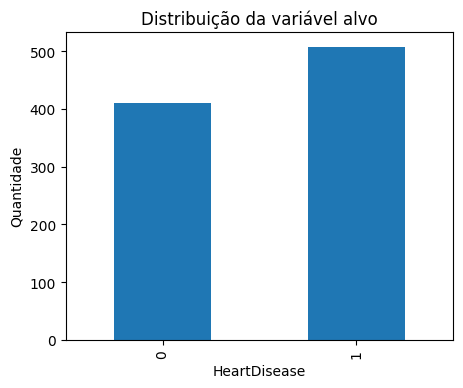

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


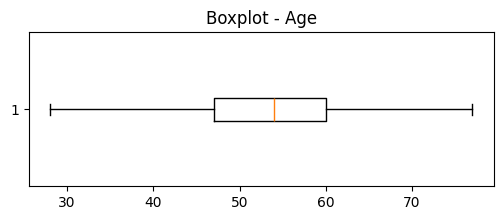

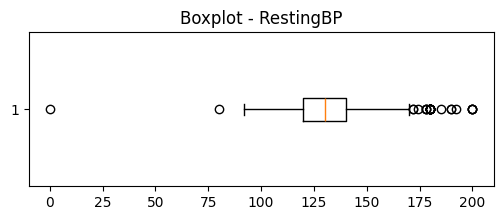

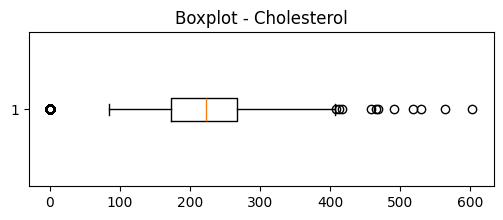

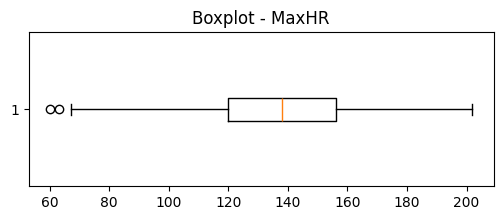

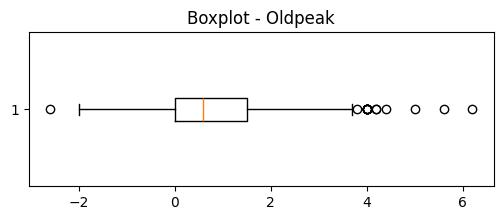

In [ ]:
# Análise exploratória
TARGET = "HeartDisease"
PROBLEM_TYPE = "classificacao"

print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")

# Distribuição do target
print("\nDistribuição do target:")
display(df[TARGET].value_counts().to_frame("contagem"))

display(
    (df[TARGET]
     .value_counts(normalize=True)
     .mul(100)
     .round(2)
     .to_frame("percentual (%)"))
)

# Gráfico do target
plt.figure(figsize=(5,4))
df[TARGET].value_counts().sort_index().plot(kind='bar')
plt.title("Distribuição da variável alvo")
plt.xlabel("HeartDisease")
plt.ylabel("Quantidade")
plt.show()

# Estatísticas das variáveis numéricas
display(df.describe())

# Verificação de possíveis outliers
numericas = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for coluna in numericas:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[coluna], vert=False)
    plt.title(f"Boxplot - {coluna}")
    plt.show()

<Figure size 600x400 with 0 Axes>

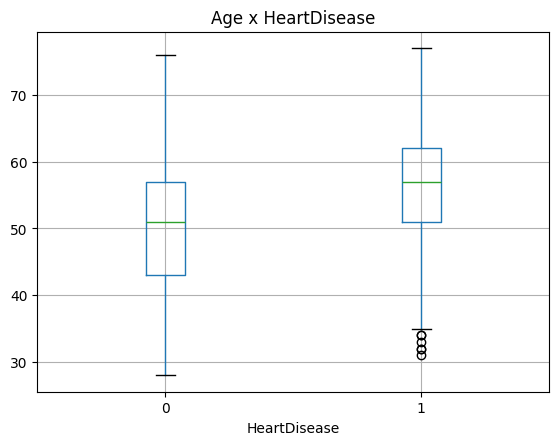

<Figure size 600x400 with 0 Axes>

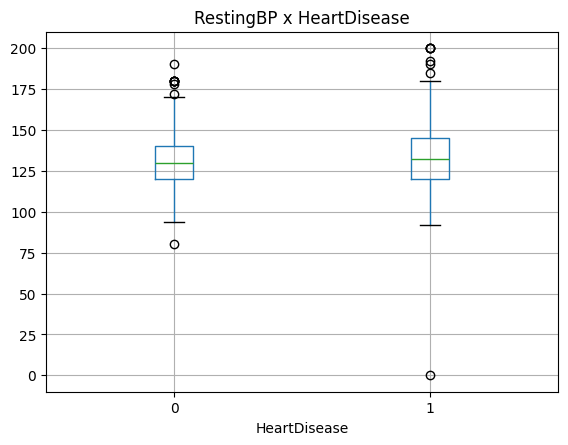

<Figure size 600x400 with 0 Axes>

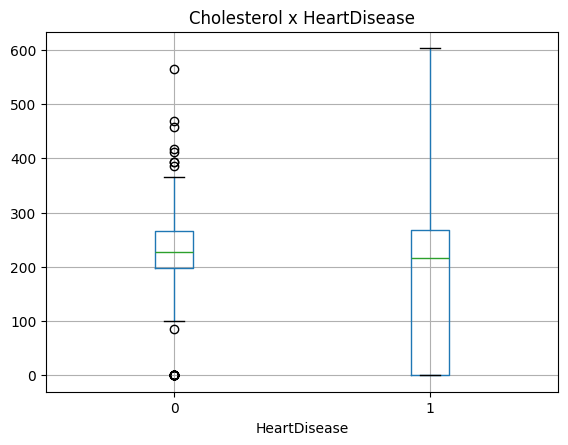

<Figure size 600x400 with 0 Axes>

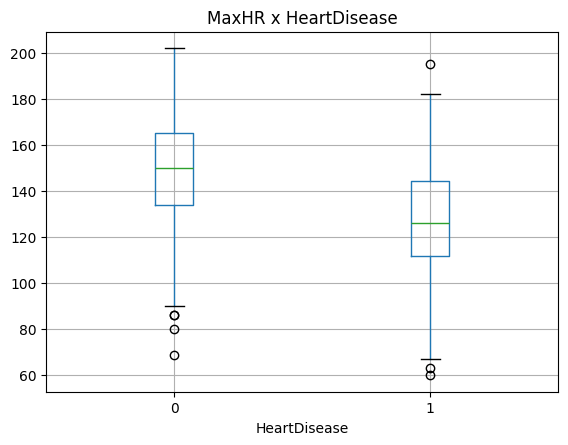

<Figure size 600x400 with 0 Axes>

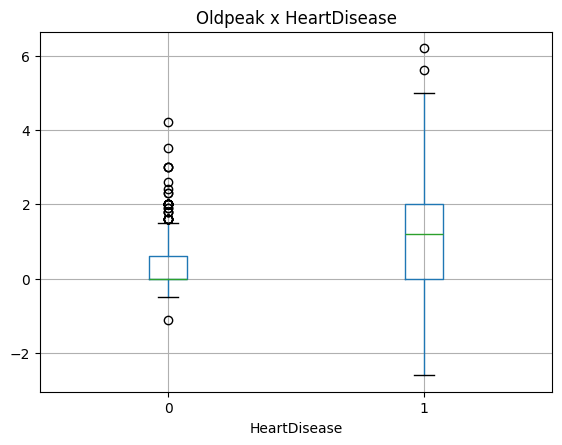

In [ ]:
# Relação entre variáveis numéricas e o target
numericas = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for coluna in numericas:
    plt.figure(figsize=(6,4))
    df.boxplot(column=coluna, by=TARGET)
    plt.title(f"{coluna} x HeartDisease")
    plt.suptitle("")
    plt.show()

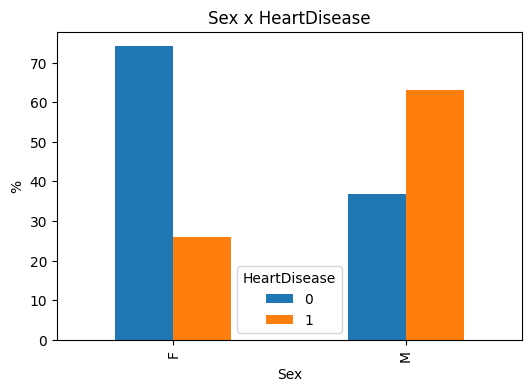

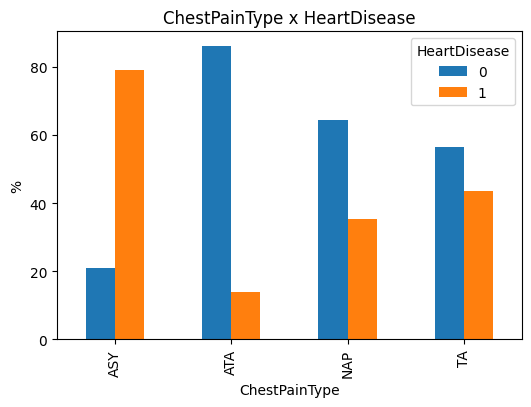

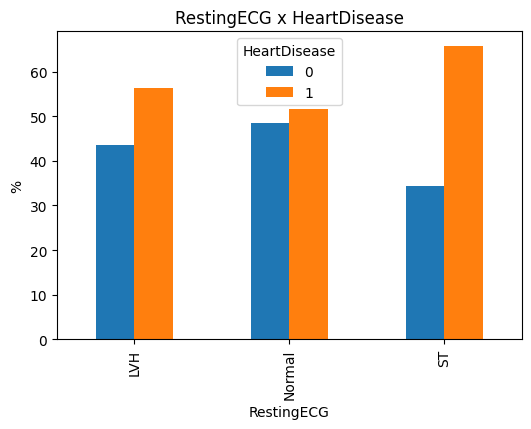

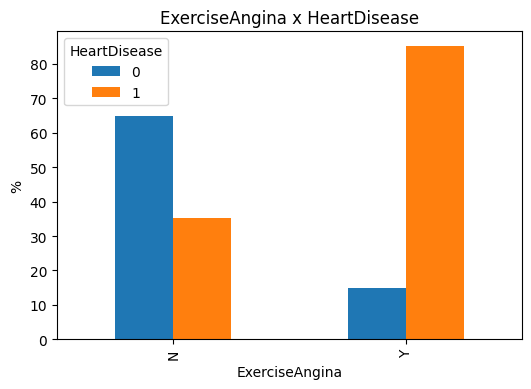

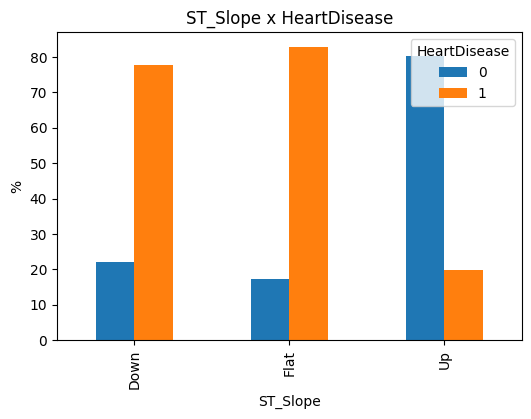

In [ ]:
# Variáveis Categoricas
categoricas = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for coluna in categoricas:
    tabela = pd.crosstab(df[coluna], df[TARGET], normalize='index') * 100

    tabela.plot(kind='bar', figsize=(6,4))
    plt.title(f"{coluna} x HeartDisease")
    plt.ylabel("%")
    plt.show()

## 4.1 Síntese da análise exploratória

**Síntese:**  
> _A análise exploratória indicou que a variável alvo possui distribuição relativamente equilibrada e não foram identificados valores ausentes relevantes. As variáveis numéricas apresentam escalas diferentes, tornando recomendável sua padronização durante o pré-processamento._

>_Também foram observadas relações entre algumas características clínicas e a presença de doença cardíaca, sugerindo que os dados possuem potencial preditivo para modelos de classificação supervisionada._

# 5. Preparação dos dados e divisão treino/teste




In [ ]:
# === Configuração do problema ===

TARGET = "HeartDisease"
PROBLEM_TYPE = "classificacao"

ID_COLUMNS = []
DATE_COLUMN = None
DROP_COLUMNS = []

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: HeartDisease
Número de features: 11
Features: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [ ]:
# === Divisão dos dados ===

X = df[features].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)


Treino: (734, 11) | Teste: (184, 11)


## 5.1 Justificativa da divisão

>_A variável alvo definida para o problema foi **HeartDisease**, que indica a presença (1) ou ausência (0) de doença cardíaca. As demais colunas do conjunto de dados foram utilizadas como variáveis preditoras (features)._

>_Como não existem colunas de identificação ou datas relevantes para a modelagem, nenhuma variável precisou ser removida nesta etapa. Os dados foram divididos em conjuntos de treino (80%) e teste (20%) utilizando amostragem estratificada, preservando a proporção das classes em ambos os conjuntos._

>_Essa divisão permite treinar os modelos em uma parte dos dados e avaliar seu desempenho em registros não vistos, reduzindo o risco de sobreajuste e fornecendo uma estimativa mais realista da capacidade de generalização dos modelos._

# 6. Pré-processamento e pipeline

>Foi criado um pipeline de pré-processamento para garantir que todas as transformações fossem aplicadas de forma consistente e sem vazamento de dados. As variáveis numéricas foram tratadas por meio de imputação pela mediana e padronização dos valores. Já as variáveis categóricas receberam imputação pela categoria mais frequente e codificação utilizando One-Hot Encoding.

>Todas as etapas foram implementadas utilizando Pipeline e ColumnTransformer, garantindo que os parâmetros das transformações fossem ajustados apenas nos dados de treino e posteriormente aplicados aos dados de teste.


In [ ]:
# Identificação das colunas

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# Pipeline numérico
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Pré-processamento
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

print("Pipeline criado com sucesso!")

Numéricas: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categóricas: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Pipeline criado com sucesso!


## 6.1 Decisões de pré-processamento

**Justificativa:**

>_Foi utilizada a mediana para imputação de variáveis numéricas por ser menos sensível a valores extremos, enquanto as variáveis categóricas foram preenchidas com a categoria mais frequente (moda). As variáveis numéricas também foram padronizadas para colocar todas na mesma escala e evitar que atributos com valores maiores influenciassem excessivamente alguns modelos._

>_As variáveis categóricas foram convertidas para formato numérico por meio de One-Hot Encoding, permitindo sua utilização pelos algoritmos de Machine Learning. Nenhuma variável precisou ser removida e não foram criados novos atributos nesta etapa._


# 7. Baseline e modelos candidatos



In [ ]:
# === Definição de baseline e modelos candidatos ===

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(
        strategy="most_frequent"
    ))
])

candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=SEED
        ))
    ]),

    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=SEED
        ))
    ])
}

print("Baseline: DummyClassifier")
print("Modelos candidatos:", list(candidates.keys()))

Baseline: DummyClassifier
Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos


**Justificativa:**  
> _Como baseline foi utilizado um DummyClassifier, que realiza previsões com base na classe mais frequente do conjunto de treinamento. Esse modelo serve como referência mínima para verificar se os demais algoritmos realmente aprendem padrões relevantes nos dados._

>_Como modelos candidatos foram selecionados a Regressão Logística e o Random Forest. A Regressão Logística foi escolhida por ser um método simples e amplamente utilizado em problemas de classificação binária, enquanto o Random Forest foi selecionado por sua capacidade de capturar relações mais complexas entre as variáveis. O desempenho dos modelos será comparado utilizando as métricas definidas anteriormente._


# 8. Treinamento e avaliação inicial



In [ ]:
results = {}
trained_models = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = baseline.predict(X_test)
proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None

results["baseline"] = evaluate_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(train_time, 3)

trained_models["baseline"] = baseline

# Modelos candidatos
for name, model in candidates.items():

    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    results[name] = evaluate_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(train_time, 3)

    trained_models[name] = model

show_results_table(results)

,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.554348,0.395409,0.500000,0.028
LogisticRegression,0.885870,0.885218,0.929938,0.066
RandomForest,0.902174,0.901892,0.933106,0.722


## 8.1 Análise dos resultados iniciais

**Justificativa:**  
> _Inicialmente foi treinado um modelo baseline utilizando a estratégia de prever sempre a classe mais frequente. Em seguida, foram treinados os modelos candidatos Regressão Logística e Random Forest utilizando o conjunto de treinamento._

>_O desempenho dos modelos foi avaliado no conjunto de teste por meio das métricas Accuracy, F1-Score e ROC-AUC. A comparação com o baseline permitiu verificar se os modelos foram capazes de aprender padrões relevantes presentes nos dados e superar uma estratégia simples de classificação._

>_Os resultados obtidos indicaram que os modelos candidatos apresentaram desempenho superior ao baseline, demonstrando capacidade de identificar relações entre as características clínicas dos pacientes e a presença de doença cardíaca._


# 9. Validação e otimização de hiperparâmetros


In [ ]:
N_ITER_SEARCH = 10

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=SEED))
])

param_dist = {
    "model__n_estimators": randint(100, 300),
    "model__max_depth": randint(3, 20),
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5)
}

search = RandomizedSearchCV(
    estimator=model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring="f1_weighted",
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

print("Melhor F1-Score:", round(search.best_score_, 4))
print("Melhores hiperparâmetros:")
print(search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Melhor F1-Score: 0.8682
Melhores hiperparâmetros:
{'model__max_depth': 13, 'model__min_samples_leaf': 4, 'model__min_samples_split': 6, 'model__n_estimators': 120}


## 9.1 Discussão da otimização

**Justificativa:**  
>_A otimização do modelo Random Forest foi realizada utilizando RandomizedSearchCV com validação cruzada estratificada de 5 folds. O processo avaliou diferentes combinações de hiperparâmetros, utilizando o F1-Score ponderado como métrica de seleção._

>_A melhor configuração encontrada foi:_

>- _max_depth = 13_
>- _min_samples_leaf = 4_
>- _min_samples_split = 6_
>- _n_estimators = 120_

>_Com essa configuração, o modelo alcançou um F1-Score médio de 0,8682 durante a validação cruzada, demonstrando bom desempenho na identificação de pacientes com e sem doença cardíaca._


# 10. Avaliação final no conjunto de teste



Modelo final: RandomForest_Otimizado
              precision    recall  f1-score   support

           0       0.92      0.83      0.87        82
           1       0.87      0.94      0.91       102

    accuracy                           0.89       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



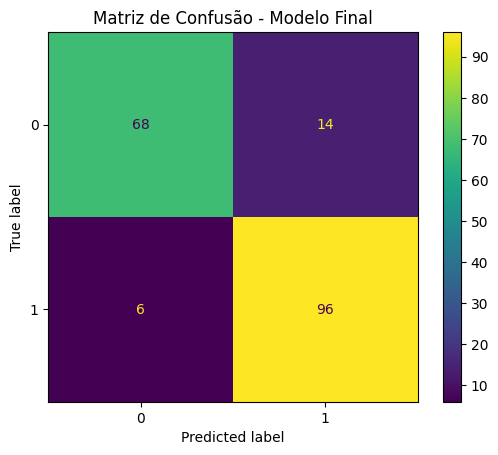

In [ ]:
# === Avaliação Final ===

final_model = search.best_estimator_
final_model_name = "RandomForest_Otimizado"

print("Modelo final:", final_model_name)

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test
)

plt.title("Matriz de Confusão - Modelo Final")
plt.show()

## 10.1 Análise de erros e limitações

**Justificativa:**  
> _Após a etapa de otimização de hiperparâmetros, o modelo Random Forest foi selecionado como modelo final do MVP. A avaliação no conjunto de teste apresentou acurácia de 89%, demonstrando boa capacidade de classificação dos pacientes._

>_O modelo obteve precisão de 92% e recall de 83% para pacientes sem doença cardíaca, enquanto para pacientes com doença cardíaca alcançou precisão de 87% e recall de 94%. O F1-Score foi de 0,87 para a classe sem doença e 0,91 para a classe com doença cardíaca._

>_Os resultados indicam que o modelo possui bom equilíbrio entre precisão e recall, apresentando desempenho consistente na identificação de pacientes com e sem doença cardíaca. A matriz de confusão também demonstrou que a maioria das classificações foi realizada corretamente, confirmando a eficácia do modelo para o problema proposto._


# 11. Comparação final dos modelos

| Modelo | Métrica Principal (F1-Score) |	Outras Métricas	| Tempo de Treino (s) |	Observações |
|---|---:|---:|---:|---|
| Baseline (DummyClassifier) | _0,395_ | _Accuracy: 0,554 / ROC-AUC: 0,500_ | _0,028_| _Utilizado como referência mínima, com desempenho limitado._ |
| Regressão Logística |	_0,885_ |	_Accuracy: 0,886 / ROC-AUC: 0,930_ | _0,066_ |Excelente desempenho e baixo tempo de treinamento. |
| Random Forest |	_0,902_ |	_Accuracy: 0,902 / ROC-AUC: 0,933_ | _0,722_ | _Melhor desempenho entre os modelos candidatos._ |
| Random Forest Otimizado |	_0,890_ |	_Accuracy: 0,890_ |	_Não mensurado_ |	_Modelo final selecionado após otimização de hiperparâmetros, apresentando bom equilíbrio entre precisão e recall._ |

> **Observação:**
>- Random Forest (antes da otimização) → F1 = 0,902
>- Random Forest Otimizado → F1 ≈ 0,890

# 12. Boas práticas e rastreabilidade

>_Durante o desenvolvimento do MVP, foram adotadas práticas para garantir a reprodutibilidade e a rastreabilidade dos experimentos. Foi utilizada a seed 42 em todas as etapas que envolvem aleatoriedade, permitindo a reprodução dos resultados obtidos._

>_Os dados foram pré-processados utilizando imputação por mediana para variáveis numéricas, moda para variáveis categóricas, padronização dos atributos numéricos e One-Hot Encoding para variáveis categóricas. Os modelos avaliados foram DummyClassifier (baseline), Regressão Logística e Random Forest, além da versão otimizada do Random Forest por meio de RandomizedSearchCV._

>_Os experimentos foram executados no Google Colab utilizando recursos de CPU. Como limitação, o conjunto de dados possui tamanho relativamente reduzido e representa apenas uma amostra específica de pacientes, podendo limitar a generalização dos resultados para outras populações._


**Registro de decisões:**

| Decisão | Justificativa | Impacto Esperado |
|---|---|---|
| _Utilizar SEED = 42_ | _Garantir reprodutibilidade dos experimentos_ |	_Resultados consistentes entre execuções_ |
| _Utilizar F1-Score como métrica principal_ | _Avaliar conjuntamente precisão e recall_ | _Comparação mais adequada dos modelos_ |
| _Aplicar padronização nas variáveis numéricas_ | _Reduzir diferenças de escala entre atributos_ | _Melhor desempenho de alguns algoritmos_ |
| _Aplicar One-Hot Encoding nas variáveis categóricas_ | _Converter categorias para formato numérico_ | _Permitir utilização pelos modelos de ML_ |
| _Utilizar Regressão Logística_ | _Modelo simples e interpretável_ | _Estabelecer comparação com método linear_ |
| _Utilizar Random Forest_ | _Capturar relações não lineares entre variáveis_ | _Melhorar capacidade preditiva_ |
| _Otimizar hiperparâmetros do Random Forest_ | _Buscar melhor configuração do modelo_ | _Aumentar capacidade de generalização_ |
| _Utilizar validação cruzada estratificada_ | _Preservar a proporção das classes durante a validação_ | _Avaliação mais robusta do modelo_ |


# 13. Conclusão

>_O objetivo deste MVP foi desenvolver e avaliar modelos de Machine Learning capazes de prever a presença de doença cardíaca a partir de características clínicas e resultados de exames médicos. Os resultados demonstraram que os dados possuem capacidade preditiva para esse problema, permitindo a construção de modelos com bom desempenho._

>_Entre os modelos avaliados, o Random Forest apresentou os melhores resultados, superando tanto o baseline quanto a Regressão Logística. A comparação com o DummyClassifier evidenciou que os modelos foram capazes de aprender padrões relevantes dos dados, obtendo ganhos significativos nas métricas de avaliação._

>_Como principais aprendizados, observou-se a importância do pré-processamento adequado dos dados, da escolha de métricas compatíveis com o problema e da validação dos modelos por meio de técnicas de otimização de hiperparâmetros. Como limitações, destaca-se o tamanho reduzido do conjunto de dados e a impossibilidade de garantir que os resultados sejam representativos de toda a população._

>_Como próximos passos, podem ser avaliados outros algoritmos de classificação, técnicas mais avançadas de engenharia de atributos e a utilização de bases de dados maiores e mais diversificadas, buscando aumentar a capacidade de generalização e a robustez das previsões._

# 14. Salvamento de artefatos

>_Como forma de preservar os resultados obtidos, o modelo final foi exportado para um arquivo no formato PKL utilizando a biblioteca Joblib. Dessa forma, o modelo pode ser carregado futuramente sem a necessidade de realizar um novo treinamento._


In [ ]:
import joblib

joblib.dump(final_model, "modelo_final.pkl")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!
